In [2]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Load and preprocess MNIST

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
len(train_dataset)
len(test_dataset)

60000

10000

In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [6]:
for batch in train_loader:
  images, labels = batch
  images.shape
  labels.shape
  break

torch.Size([32, 1, 28, 28])

torch.Size([32])

In [7]:
images, labels = next(iter(train_loader))

In [8]:
images.shape  # batch size, channel, height, width
labels.shape
images.min()
images.max()

torch.Size([32, 1, 28, 28])

torch.Size([32])

tensor(-1.)

tensor(1.)

In [9]:
len(train_loader)
len(test_loader)

1875

313

In [10]:
images[0][0].shape
images[0, 0].shape

torch.Size([28, 28])

torch.Size([28, 28])

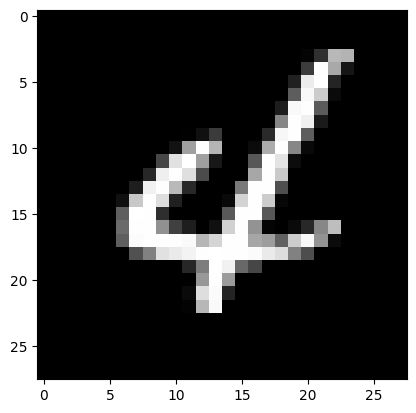

In [11]:
import matplotlib.pyplot as plt
_ = plt.imshow(images[0][0], cmap='gray')

# MLP architecture

In [12]:
import torch.nn.functional as F


class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()

    self.layer1 = nn.Linear(784, 128)
    self.layer2 = nn.Linear(128, 64)
    self.layer3 = nn.Linear(64, 10)
    self.dropout = nn.Dropout(0.2)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = F.relu(self.layer1(x))
    x = self.dropout(x)

    x = F.relu(self.layer2(x))
    x = self.dropout(x)

    x = self.layer3(x)

    return x

In [13]:
model_mlp = MLP()
print(model_mlp)

total = 0
for name, param in model_mlp.named_parameters():
  count = param.numel()
  total += count
  print(f'{name:15s} | {str(param.shape):25s} | {count}')

print('total params:', total)

MLP(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
layer1.weight   | torch.Size([128, 784])    | 100352
layer1.bias     | torch.Size([128])         | 128
layer2.weight   | torch.Size([64, 128])     | 8192
layer2.bias     | torch.Size([64])          | 64
layer3.weight   | torch.Size([10, 64])      | 640
layer3.bias     | torch.Size([10])          | 10
total params: 109386


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)

In [15]:
logits = torch.tensor([0.1, 2, 0.1], dtype=float)
labels = torch.tensor([0, 1, 0], dtype=float)

F.softmax(logits, dim=0).round(decimals=2)
criterion(logits, labels)

tensor([0.1200, 0.7700, 0.1200], dtype=torch.float64)

tensor(0.2617, dtype=torch.float64)

In [16]:
history = {
    'train_loss': [],
}

In [17]:
NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
  print(f'THIS IS EPOCH {epoch+1}')

  for batch_idx, (images, labels) in enumerate(train_loader):
    # 1. clear the accumulated grads
    optimizer.zero_grad()

    # 2. forward pass to get the outputs
    outputs = model_mlp(images)

    # 3. calculate the loss
    loss = criterion(outputs, labels)

    # 4. backward pass to calculate grads
    loss.backward()

    # 5. update model parameters
    optimizer.step()

    if batch_idx % 200 == 0:
      print(f'  Batch: {batch_idx:>4}, Loss: {loss.item():.4f}')
      history['train_loss'].append(loss.item())

THIS IS EPOCH 1
  Batch:    0, Loss: 2.3051
  Batch:  200, Loss: 0.9421
  Batch:  400, Loss: 0.5024
  Batch:  600, Loss: 0.7061
  Batch:  800, Loss: 0.1544
  Batch: 1000, Loss: 0.4480
  Batch: 1200, Loss: 0.2923
  Batch: 1400, Loss: 0.1917
  Batch: 1600, Loss: 0.2563
  Batch: 1800, Loss: 0.3050


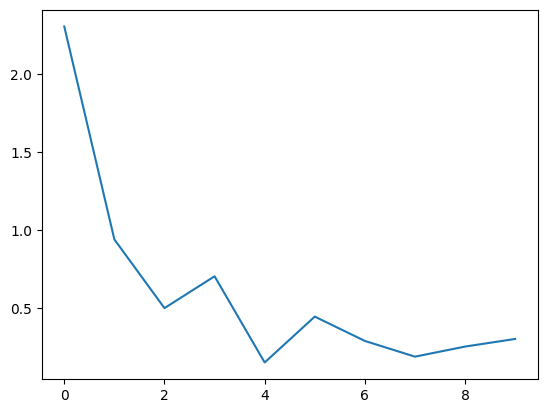

In [18]:
_ = plt.plot(history['train_loss'])